# Reproducible supplement — agent-effectiveness benchmark report

This notebook regenerates **every figure and number** in
`docs/reference/benchmark-report.md` directly from the raw run data committed
under `bench/results/`. Nothing is hardcoded: each statistic is recomputed from
the per-attempt records, and each figure is written to `bench/reports/knowledge-layer/figures/`.

**Requirements:** `pip install -r bench/reports/knowledge-layer/requirements.txt`
(`numpy`, `pandas`, `matplotlib`). No API key, no running platform, and no
network access are needed — the committed `results.json` files are the only
input.

**How to run:** from the repository root,
`jupyter nbconvert --to notebook --execute --inplace bench/reports/knowledge-layer/report.ipynb`,
or open it and Run All. The notebook resolves `bench/results/` relative to its
own location, so it runs unchanged from either the repo root or `bench/reports/knowledge-layer/`.

**Provenance note.** Two client paths were used: the ablation (S1–S3, S5) ran on
the Anthropic API adapter; the cold-start learning curve ran on the `claude-cli`
adapter. The two paths are **not** accuracy-comparable (different client
version, injected system prompt) and are reported as complementary sub-studies,
never on one leaderboard. Every table below prints the run directory it was
computed from.

## 0. Setup — data loaders and the bootstrap estimator

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Resolve bench/results/ relative to this notebook, robust to launch cwd ---
def find_results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "bench" / "results"
        if cand.is_dir():
            return cand
        cand = base / "results"
        if cand.is_dir() and (base.name == "bench"):
            return cand
    raise FileNotFoundError("could not locate bench/results/ from " + str(Path.cwd()))

RESULTS = find_results_dir()
REPO_ROOT = RESULTS.parent.parent
FIGDIR = (RESULTS.parent / "reports" / "knowledge-layer" / "figures")  # canonical, next to the notebook
DOCS_FIGDIR = (REPO_ROOT / "docs" / "reference" / "benchmark-figures")  # served by the docs site
for d in (FIGDIR, DOCS_FIGDIR):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    '''Write each figure to the canonical figures dir AND the docs-served copy so
    the report renders both in the repo and on the mkdocs site.'''
    for d in (FIGDIR, DOCS_FIGDIR):
        fig.savefig(d / name)
    return FIGDIR / name

print("results dir:", RESULTS)
print("figures dir:", FIGDIR)
print("docs figures dir:", DOCS_FIGDIR)

# --- Reproducible bootstrap configuration ---
RNG_SEED = 930          # same integer as the benchmark dataset seed
B = 20000               # bootstrap resamples
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

def load(*parts):
    with open(RESULTS.joinpath(*parts)) as f:
        return json.load(f)

def boot_ci(flags, seed=RNG_SEED, B=B, lo=2.5, hi=97.5):
    '''Percentile bootstrap CI for the mean of a 0/1 array (fixed seed => reproducible).'''
    a = np.asarray(flags, dtype=float)
    n = len(a)
    if n == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(B, n))
    means = a[idx].mean(axis=1)
    return float(np.percentile(means, lo)), float(np.percentile(means, hi))

def prop_ci(num, den, seed=RNG_SEED, B=B):
    '''Bootstrap CI from a proportion num/den by reconstructing the Bernoulli sample.'''
    if den == 0:
        return (float("nan"), float("nan"))
    flags = [1] * num + [0] * (den - num)
    return boot_ci(flags, seed=seed, B=B)

def pct(x):
    return "nan" if x != x else f"{x*100:.1f}%"

# --- Plot style: light, print-legible, colourblind-safe categorical palette ---
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
ARM_COLOR = {"a0": "#8C8C8C", "a1": "#4C78A8", "a2": "#59A14F", "a3": "#E1751A"}
SINK_COLOR = {"datahub": "#B279A2", "knowledge_page": "#4C78A8"}
print("bootstrap:", f"B={B}", f"seed={RNG_SEED}")

results dir: /Users/cjimti/workspace/txn2/mcp-data-platform/bench/results
figures dir: /Users/cjimti/workspace/txn2/mcp-data-platform/bench/report/figures
docs figures dir: /Users/cjimti/workspace/txn2/mcp-data-platform/docs/reference/benchmark-figures
bootstrap: B=20000 seed=930


## 1. Single-shot ablation (S1–S3, Anthropic API)

Four arms on a fixed, seeded dataset, `k = 3` repeats per task:

- **a0** baseline — raw toolkit tools only (no enrichment, no search)
- **a1** enrichment — a0 plus semantic cross-enrichment
- **a2** knowledge — a1 plus search, the search-first gate, and knowledge pages
- **a3** lifecycle — a2 plus memory/insight capture and `apply_knowledge`

Accuracy is over graded attempts; `pass^k` is the fraction of tasks whose *all*
`k` repeats pass. CIs are the reproducible percentile bootstrap defined above.

In [2]:
ABLATION_DIR = "phase2-anthropic-k3"
ARMS = ["a0", "a1", "a2", "a3"]

def arm_attempts(arm):
    return load(ABLATION_DIR, f"full-{arm}", "results.json")["attempts"]

manifest = load(ABLATION_DIR, "full-a2", "results.json")["manifest"]
print("ablation source:", RESULTS / ABLATION_DIR)
print("model:", manifest["model"], "| provider:", manifest["llm_provider"],
      "| k:", manifest["k"], "| platform:", manifest["platform_version"])

rows = []
for arm in ARMS:
    att = arm_attempts(arm)
    correct = [1 if a["correct"] else 0 for a in att]
    lo, hi = boot_ci(correct)
    bytask = {}
    for a in att:
        bytask.setdefault(a["task_id"], []).append(1 if a["correct"] else 0)
    passk = np.mean([1 if all(v) else 0 for v in bytask.values()])
    rows.append({
        "arm": arm, "graded": len(att),
        "accuracy": np.mean(correct), "ci_lo": lo, "ci_hi": hi,
        "pass^k": passk,
        "median_calls": int(np.median([a["tool_calls"] for a in att])),
        "median_wall_s": np.median([a["wall_ms"] for a in att]) / 1000,
        "harness_fails": sum(1 for a in att if a.get("harness_failure")),
    })
ablation_overall = pd.DataFrame(rows)
disp = ablation_overall.copy()
disp["accuracy (95% CI)"] = [f"{pct(r.accuracy)} [{r.ci_lo*100:.0f}-{r.ci_hi*100:.0f}]"
                             for r in ablation_overall.itertuples()]
disp["pass^k"] = disp["pass^k"].map(pct)
print(disp[["arm","graded","accuracy (95% CI)","pass^k","median_calls","median_wall_s","harness_fails"]]
      .to_string(index=False))

ablation source: /Users/cjimti/workspace/txn2/mcp-data-platform/bench/results/phase2-anthropic-k3
model: claude-sonnet-5 | provider: anthropic | k: 3 | platform: v1.102.0-9-gadfb9d90-dirty
arm  graded accuracy (95% CI) pass^k  median_calls  median_wall_s  harness_fails
 a0     261     83.1% [79-87]  80.5%             7         13.983              0
 a1     261     87.4% [83-91]  86.2%             7         13.938              0
 a2     261    98.5% [97-100]  97.7%             9         27.363              0
 a3     261    98.1% [96-100]  96.6%             9         27.019              0


In [3]:
# Accuracy by suite (S1, S2, S3) per arm
SUITES = ["s1", "s2", "s3"]
suite_rows = []
for arm in ARMS:
    att = arm_attempts(arm)
    row = {"arm": arm}
    for s in SUITES:
        c = [1 if a["correct"] else 0 for a in att if a["suite"] == s]
        lo, hi = boot_ci(c)
        row[s] = f"{pct(np.mean(c))} [{lo*100:.0f}-{hi*100:.0f}]"
    suite_rows.append(row)
suite_acc = pd.DataFrame(suite_rows)
print("Accuracy by suite (95% CI):")
print(suite_acc.to_string(index=False))

# S3 knowledge-trap accuracy by class
TRAPS = ["deprecated_table","fiscal_calendar","freshness_cutoff","net_revenue","tier_boundary","units_cents"]
trap_rows = []
for t in TRAPS:
    row = {"trap_class": t}
    for arm in ARMS:
        c = [1 if a["correct"] else 0 for a in arm_attempts(arm) if t in a.get("trap_classes", [])]
        row[arm] = pct(np.mean(c))
        row[arm + "_n"] = len(c)
    trap_rows.append(row)
s3_traps = pd.DataFrame(trap_rows)
print("\nS3 trap-class accuracy (n identical across arms by construction):")
print(s3_traps[["trap_class","a0","a1","a2","a3","a0_n"]]
      .rename(columns={"a0_n":"n_per_arm"}).to_string(index=False))

Accuracy by suite (95% CI):
arm               s1               s2             s3
 a0   98.0% [94-100] 100.0% [100-100]  42.7% [32-53]
 a1   98.0% [94-100] 100.0% [100-100]  57.3% [47-68]
 a2 100.0% [100-100]   97.8% [95-100] 98.7% [96-100]
 a3   98.0% [94-100]   97.8% [95-100] 98.7% [96-100]

S3 trap-class accuracy (n identical across arms by construction):
      trap_class    a0     a1     a2     a3  n_per_arm
deprecated_table 95.2%  95.2% 100.0% 100.0%         21
 fiscal_calendar  0.0%   0.0% 100.0% 100.0%         15
freshness_cutoff 91.7% 100.0% 100.0% 100.0%         12
     net_revenue 21.2%  48.5% 100.0% 100.0%         33
   tier_boundary  0.0%   0.0%  93.3% 100.0%         15
     units_cents 61.9%  88.1%  97.6%  97.6%         42


In [4]:
# S3 platform effect: delta a2-a0 with a bootstrap CI on the DIFFERENCE
def delta_ci(arm_a, arm_b, suite="s3", seed=RNG_SEED, B=B):
    a = np.array([1 if x["correct"] else 0 for x in arm_attempts(arm_a) if x["suite"] == suite], float)
    b = np.array([1 if x["correct"] else 0 for x in arm_attempts(arm_b) if x["suite"] == suite], float)
    rng = np.random.default_rng(seed)
    diffs = b[rng.integers(0, len(b), (B, len(b)))].mean(1) - a[rng.integers(0, len(a), (B, len(a)))].mean(1)
    return b.mean() - a.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

for arm in ["a1", "a2", "a3"]:
    d, lo, hi = delta_ci("a0", arm)
    print(f"S3 accuracy delta {arm} - a0 = {d*100:+.1f} pts   95% CI [{lo*100:+.0f} to {hi*100:+.0f}]")

S3 accuracy delta a1 - a0 = +14.7 pts   95% CI [-1 to +31]
S3 accuracy delta a2 - a0 = +56.0 pts   95% CI [+44 to +67]


S3 accuracy delta a3 - a0 = +56.0 pts   95% CI [+44 to +67]


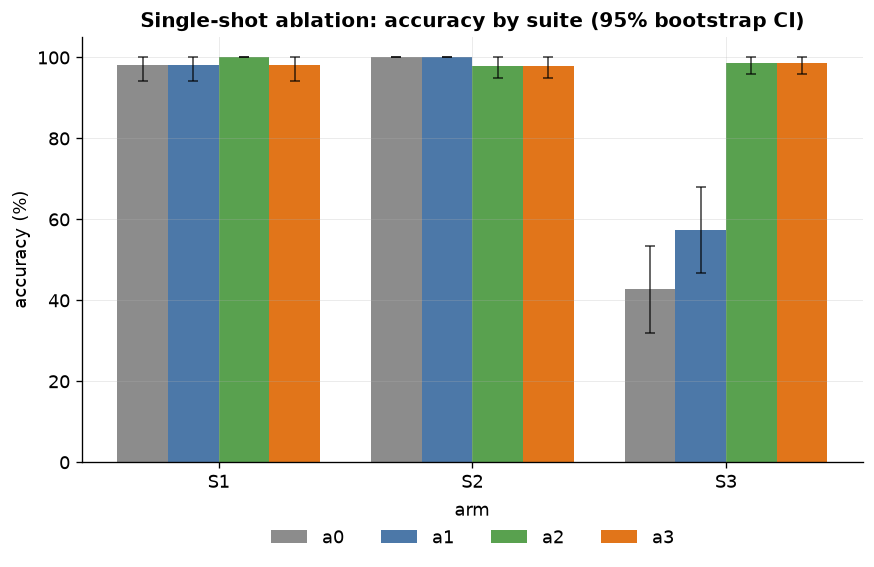

wrote /Users/cjimti/workspace/txn2/mcp-data-platform/bench/report/figures/fig3_ablation_by_suite.png and docs copy


In [5]:
# FIGURE 3 — ablation accuracy by suite, grouped bars with CI whiskers
fig, ax = plt.subplots(figsize=(8.4, 4.6))
x = np.arange(len(SUITES)); w = 0.2
for i, arm in enumerate(ARMS):
    att = arm_attempts(arm)
    means, los, his = [], [], []
    for s in SUITES:
        c = [1 if a["correct"] else 0 for a in att if a["suite"] == s]
        m = np.mean(c); lo, hi = boot_ci(c)
        means.append(m*100); los.append((m-lo)*100); his.append((hi-m)*100)
    ax.bar(x + (i-1.5)*w, means, w, label=arm, color=ARM_COLOR[arm],
           yerr=[los, his], capsize=3, error_kw=dict(lw=1, alpha=0.7))
ax.set_xticks(x); ax.set_xticklabels([s.upper() for s in SUITES])
ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 105)
ax.set_title("Single-shot ablation: accuracy by suite (95% bootstrap CI)")
ax.legend(title="arm", ncol=4, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.24))
save_fig(fig, "fig3_ablation_by_suite.png")
plt.show()
print("wrote", FIGDIR / "fig3_ablation_by_suite.png", "and docs copy")

## 2. Cold-start knowledge-growth curve (`claude-cli`, sonnet)

The platform starts from an **empty enrichment layer** (entities present, no
descriptions/tags/glossary/pages). Six lessons are taught one at a time; each
captured insight is promoted to a sink (a DataHub aspect or a knowledge page).
After each promotion a **fixed 25-task S3 evaluation set** is re-run
(`k` repeats). Checkpoint 0 is the empty-layer baseline. The independent
variable is the number of promoted insights.

In [6]:
COLD = {
    "K=3 (headline)":      "cold-start-a3-20260717-142008-3064",
    "K=1":                 "cold-start-a3-20260717-085742-89538",
    "K=1 capture-only":    "cold-start-a3-20260716-234306-5181",
}
def cold(run):
    return load(run, "results.json")

def curve(run):
    d = cold(run); pts = []
    for cp in d["checkpoints"]:
        graded = [a for a in cp["attempts"] if a.get("graded")]
        c = [1 if a["correct"] else 0 for a in graded]
        lo, hi = boot_ci(c)
        pts.append({"cp": cp["index"], "promoted": cp["promoted_so_far"],
                    "acc": np.mean(c), "lo": lo, "hi": hi, "graded": len(graded)})
    return d, pd.DataFrame(pts)

for name, run in COLD.items():
    d, df = curve(run)
    man, met = d["manifest"], d["metrics"]
    print(f"\n{name}  <{run}>")
    print(f"  client={man.get('client_version')} model={man['model']} k={man['k']} "
          f"promoted={met['lessons_promoted']}/{met['lessons']} captured={met['lessons_captured']} "
          f"harness_failures={met['harness_failures']}")
    print(f"  baseline={pct(met['baseline_accuracy'])}  final={pct(met['final_accuracy'])}  "
          f"lift={met['accuracy_lift']*100:+.1f} pts")
    print("  " + "  ".join(f"cp{r.cp}:{pct(r.acc)}" for r in df.itertuples()))


K=3 (headline)  <cold-start-a3-20260717-142008-3064>
  client=2.1.212 (Claude Code) model=sonnet k=3 promoted=5/6 captured=5 harness_failures=0
  baseline=48.0%  final=90.7%  lift=+42.7 pts
  cp0:48.0%  cp1:41.3%  cp2:50.7%  cp3:70.7%  cp4:70.7%  cp5:96.0%  cp6:90.7%

K=1  <cold-start-a3-20260717-085742-89538>
  client=2.1.212 (Claude Code) model=sonnet k=1 promoted=5/6 captured=5 harness_failures=1
  baseline=44.0%  final=100.0%  lift=+56.0 pts
  cp0:44.0%  cp1:48.0%  cp2:62.5%  cp3:76.0%  cp4:68.0%  cp5:100.0%  cp6:100.0%

K=1 capture-only  <cold-start-a3-20260716-234306-5181>
  client=2.1.212 (Claude Code) model=sonnet k=1 promoted=0/6 captured=5 harness_failures=5
  baseline=52.0%  final=96.0%  lift=+44.0 pts
  cp0:52.0%  cp1:40.0%  cp2:52.0%  cp3:60.0%  cp4:72.0%  cp5:96.0%  cp6:96.0%


In [7]:
# Baseline replicates: checkpoint-0 accuracy of the empty enrichment layer
BASELINE_RUNS = [
    "cold-start-a3-20260717-142008-3064",
    "cold-start-a3-20260717-085742-89538",
    "cold-start-a3-20260716-234306-5181",
    "cold-start-a3-20260716-115550-399",
    "cold-start-a3-20260716-220857-52792",
]
baseline_vals = []
for run in BASELINE_RUNS:
    d = cold(run)
    baseline_vals.append(d["metrics"]["baseline_accuracy"])
    print(f"  {run}: baseline={pct(d['metrics']['baseline_accuracy'])} "
          f"(k={d['manifest']['k']}, checkpoints={d['metrics']['checkpoints']})")
baseline_vals = np.array(baseline_vals)
print(f"\n  empty-layer floor: {sorted(round(v*100,1) for v in baseline_vals)}  "
      f"mean={pct(baseline_vals.mean())}  min={pct(baseline_vals.min())}  max={pct(baseline_vals.max())}")

  cold-start-a3-20260717-142008-3064: baseline=48.0% (k=3, checkpoints=7)
  cold-start-a3-20260717-085742-89538: baseline=44.0% (k=1, checkpoints=7)
  cold-start-a3-20260716-234306-5181: baseline=52.0% (k=1, checkpoints=7)
  cold-start-a3-20260716-115550-399: baseline=47.8% (k=1, checkpoints=1)
  cold-start-a3-20260716-220857-52792: baseline=44.0% (k=1, checkpoints=1)

  empty-layer floor: [np.float64(44.0), np.float64(44.0), np.float64(47.8), np.float64(48.0), np.float64(52.0)]  mean=47.2%  min=44.0%  max=52.0%


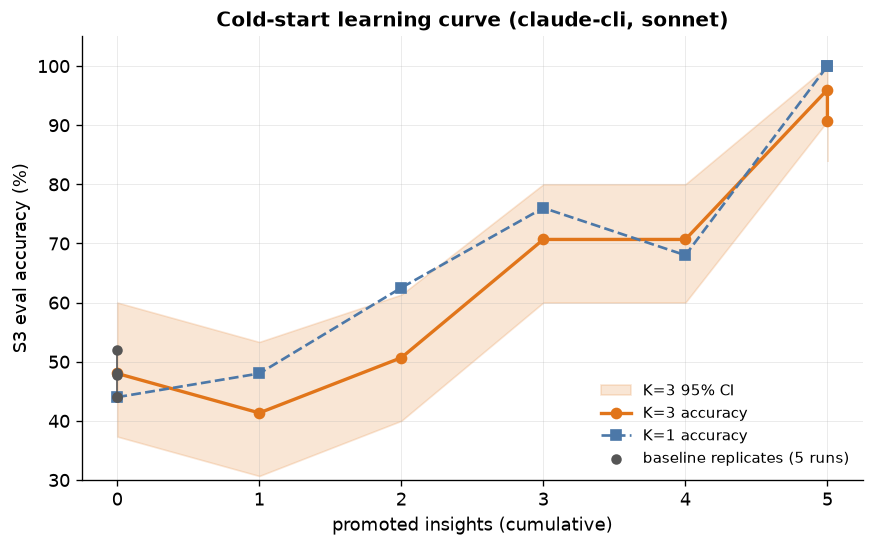

wrote /Users/cjimti/workspace/txn2/mcp-data-platform/bench/report/figures/fig1_learning_curve.png and docs copy


In [8]:
# FIGURE 1 — learning curve: K=3 with CI band, K=1 overlaid, baseline spread at x=0
_, k3 = curve(COLD["K=3 (headline)"])
_, k1 = curve(COLD["K=1"])
fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.fill_between(k3["promoted"], k3["lo"]*100, k3["hi"]*100, color=ARM_COLOR["a3"], alpha=0.18,
                label="K=3 95% CI")
ax.plot(k3["promoted"], k3["acc"]*100, "-o", color=ARM_COLOR["a3"], lw=2, label="K=3 accuracy")
ax.plot(k1["promoted"], k1["acc"]*100, "--s", color=ARM_COLOR["a1"], lw=1.6, label="K=1 accuracy")
# baseline-replicate spread as a vertical strip at x=0
ax.scatter(np.zeros_like(baseline_vals), baseline_vals*100, color="#555", s=28, zorder=5,
           label="baseline replicates (5 runs)")
ax.vlines(0, baseline_vals.min()*100, baseline_vals.max()*100, color="#555", lw=1)
ax.set_xlabel("promoted insights (cumulative)")
ax.set_ylabel("S3 eval accuracy (%)"); ax.set_ylim(30, 105)
ax.set_xticks(range(0, 6))
ax.set_title("Cold-start learning curve (claude-cli, sonnet)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
save_fig(fig, "fig1_learning_curve.png")
plt.show()
print("wrote", FIGDIR / "fig1_learning_curve.png", "and docs copy")

In [9]:
# Per-trap-class trajectory (K=3): each class vs checkpoint, with its lesson's
# promotion checkpoint and sink. The lesson list gives class -> (order, sink).
d3 = cold(COLD["K=3 (headline)"])
lessons = d3["lessons"]
# promotion checkpoint index for a class = position in lesson order + 1 (cp0 is baseline)
lesson_meta = {}
for i, L in enumerate(lessons):
    lesson_meta[L["trap_class"]] = {
        "order": i + 1, "sink": L["sink"],
        "captured": L["captured"], "promoted": bool(L.get("promoted")),
        "title": L["title"], "lesson_id": L["lesson_id"],
    }
traj = {t: [] for t in TRAPS}
for cp in d3["checkpoints"]:
    for t in TRAPS:
        bc = cp["by_trap_class"].get(t)
        traj[t].append(bc["accuracy"] if bc else np.nan)
traj_df = pd.DataFrame(traj, index=[cp["index"] for cp in d3["checkpoints"]])
print("K=3 per-trap-class accuracy by checkpoint (rows = checkpoint index):")
print((traj_df*100).round(1).to_string())
print("\nlesson metadata (class -> promotion checkpoint, sink, captured):")
for t in TRAPS:
    m = lesson_meta[t]
    print(f"  {t:18s} promoted_at_cp={m['order']:<2} sink={m['sink']:<15} "
          f"captured={m['captured']} promoted={m['promoted']}")

K=3 per-trap-class accuracy by checkpoint (rows = checkpoint index):
   deprecated_table  fiscal_calendar  freshness_cutoff  net_revenue  tier_boundary  units_cents
0             100.0              0.0              91.7         26.7              0         71.4
1             100.0              0.0              91.7         16.7              0         59.5
2             100.0              0.0              83.3         36.7              0         76.2
3             100.0             86.7              75.0         90.0              0         81.0
4              83.3             93.3              91.7         86.7              0         78.6
5             100.0             80.0             100.0         90.0            100        100.0
6              66.7             93.3             100.0         86.7            100         85.7

lesson metadata (class -> promotion checkpoint, sink, captured):
  deprecated_table   promoted_at_cp=6  sink=datahub         captured=False promoted=False
  fisca

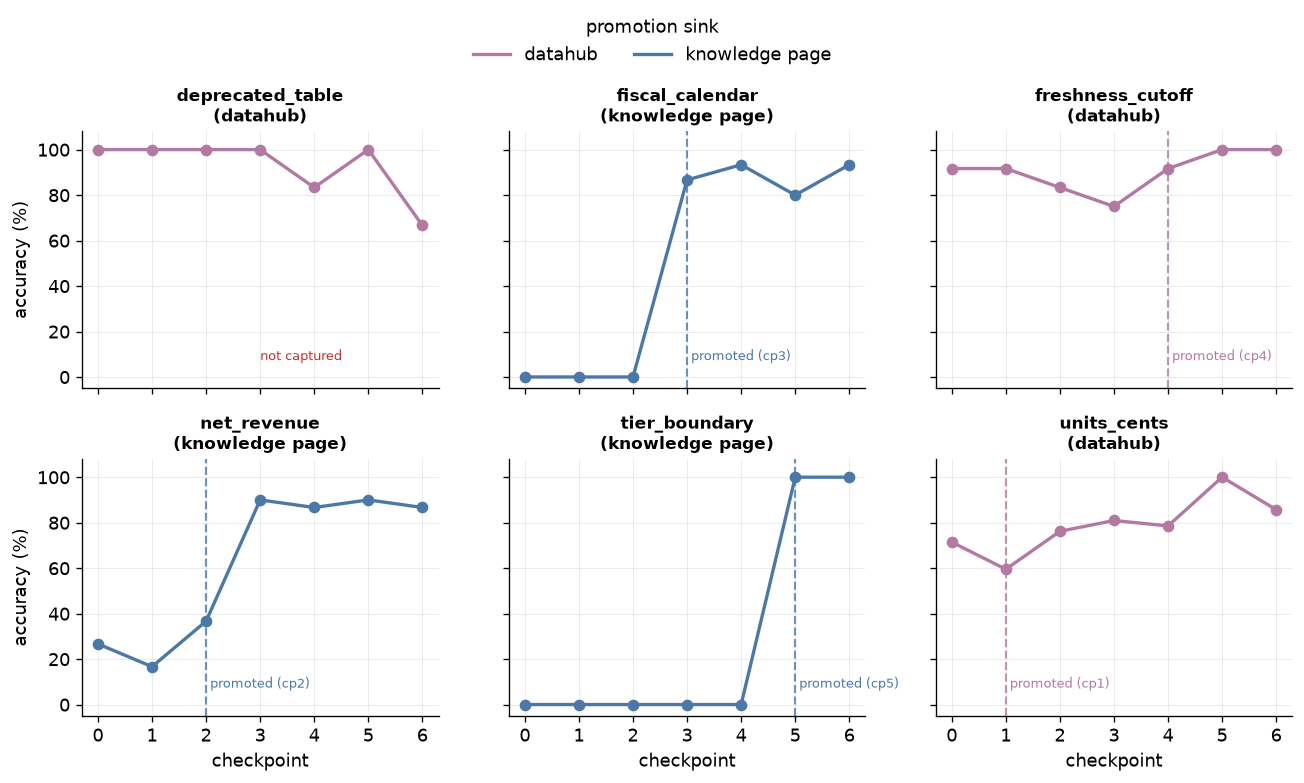

wrote /Users/cjimti/workspace/txn2/mcp-data-platform/bench/report/figures/fig2_trap_trajectories.png and docs copy


In [10]:
# FIGURE 2 — per-trap-class trajectory small-multiples (the unlock-at-checkpoint figure)
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2), sharex=True, sharey=True)
cps = list(traj_df.index)
for ax, t in zip(axes.ravel(), TRAPS):
    m = lesson_meta[t]
    col = SINK_COLOR[m["sink"]]
    ax.plot(cps, traj_df[t]*100, "-o", color=col, lw=2)
    if m["captured"] and m["promoted"]:
        ax.axvline(m["order"], color=col, ls="--", lw=1.3, alpha=0.8)
        ax.text(m["order"], 6, f" promoted (cp{m['order']})", color=col, fontsize=8, va="bottom")
    else:
        ax.text(0.5, 6, "not captured", color="#B33", fontsize=8, va="bottom",
                transform=ax.get_yaxis_transform())
    ax.set_title(f"{t}\n({m['sink'].replace('_',' ')})", fontsize=10)
    ax.set_ylim(-5, 108); ax.set_xticks(cps)
for ax in axes[-1]:
    ax.set_xlabel("checkpoint")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (%)")
# legend for sink colours
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, lw=2, label=s.replace("_"," ")) for s, c in SINK_COLOR.items()]
fig.legend(handles=handles, title="promotion sink", frameon=False, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, 1.06))
fig.suptitle("")
fig.tight_layout()
save_fig(fig, "fig2_trap_trajectories.png")
plt.show()
print("wrote", FIGDIR / "fig2_trap_trajectories.png", "and docs copy")

## 3. Memory/knowledge lifecycle (S5, Anthropic API)

The S5 suite exercises the knowledge loop across identities: a *teacher* captures
a fact and promotes it; a *learner* (a different identity) must reuse it; and a
*supersede* stage restates a fact and checks the platform detects the duplicate.
Each of the 15 protocols is run `k = 3` times (45 protocol-runs). Rates carry a
reproducible bootstrap CI over protocol-runs.

In [11]:
S5_RUN = "s5-anthropic-k3-isolated-v2"
s5 = load(S5_RUN, "lifecycle-a3.json")
s5runs = s5["runs"]; s5man = s5["manifest"]
print("S5 source:", RESULTS / S5_RUN, "| k:", s5man["k"], "| platform:", s5man["platform_version"])

# Recompute each rate as num/den over the applicable protocol-runs, with CI.
def field_rate(field, applicable=lambda r: True):
    flags = [1 if r[field] else 0 for r in s5runs if r.get(field) is not None and applicable(r)]
    lo, hi = boot_ci(flags)
    return len(flags), sum(flags), np.mean(flags) if flags else float("nan"), lo, hi

# transfer only applies where the fact was promoted; supersede fields only on update protocols
metrics_map = [
    ("capture_rate",     "captured",         lambda r: True),
    ("personal_recall",  "recall_correct",   lambda r: True),
    ("cross_transfer",   "transfer_correct", lambda r: r.get("transfer_correct") is not None),
    ("abstention",       "abstain_correct",  lambda r: True),
]
print("\nRecomputed S5 rates (95% bootstrap CI over protocol-runs):")
for label, field, appl in metrics_map:
    n, k, m, lo, hi = field_rate(field, appl)
    print(f"  {label:16s} {pct(m)} [{lo*100:.0f}-{hi*100:.0f}]   ({k}/{n})")

# harness-reported rates (num/den) for the supersede metrics and pass_k
print("\nHarness-reported rates (num/den):")
for key in ["capture_rate","personal_recall","unprompted_surface","transfer_rate",
            "update_correctness","duplicate_rate","abstention_rate","pass_k"]:
    v = s5["metrics"][key]
    print(f"  {key:20s} {pct(v['rate'])} ({v['num']}/{v['den']})")

S5 source: /Users/cjimti/workspace/txn2/mcp-data-platform/bench/results/s5-anthropic-k3-isolated-v2 | k: 3 | platform: v1.102.0-10-g32d61254-dirty

Recomputed S5 rates (95% bootstrap CI over protocol-runs):
  capture_rate     82.2% [71-93]   (37/45)
  personal_recall  84.4% [73-93]   (38/45)
  cross_transfer   46.7% [30-63]   (14/30)
  abstention       95.6% [89-100]   (43/45)

Harness-reported rates (num/den):
  capture_rate         82.2% (37/45)
  personal_recall      84.4% (38/45)
  unprompted_surface   100.0% (37/37)
  transfer_rate        46.7% (14/30)
  update_correctness   100.0% (7/7)
  duplicate_rate       42.9% (3/7)
  abstention_rate      95.6% (43/45)
  pass_k               20.0% (3/15)


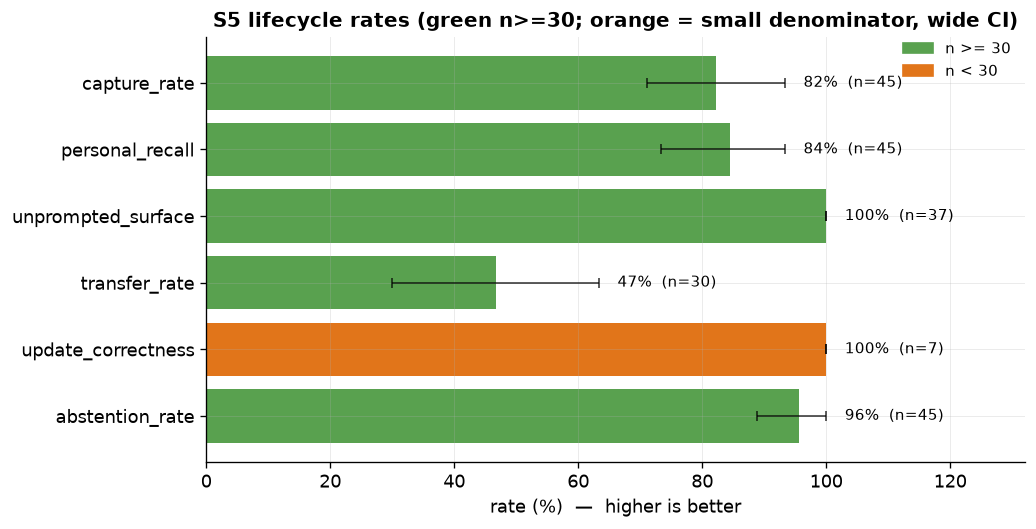

duplicate_rate (lower=better, NOT plotted): 42.9% [14-86] (3/7)
wrote /Users/cjimti/workspace/txn2/mcp-data-platform/bench/report/figures/fig4_s5_lifecycle.png and docs copy


In [12]:
# FIGURE 4 — S5 higher-is-better lifecycle rates with CI, coloured by denominator.
# duplicate_rate is inverse (lower = better) so it is NOT plotted here; it is
# reported in the prose. Each rate is bootstrapped from its harness num/den.
S5_HIGHER_BETTER = [
    ("capture_rate",       "all 30 protocol-runs"),
    ("personal_recall",    "all 30 protocol-runs"),
    ("unprompted_surface", "captured runs only"),
    ("transfer_rate",      "promote protocols only"),
    ("update_correctness", "supersede protocols only"),
    ("abstention_rate",    "all 30 protocol-runs"),
]
labels, means, los, his, dens = [], [], [], [], []
for key, _note in S5_HIGHER_BETTER:
    v = s5["metrics"][key]
    lo, hi = prop_ci(v["num"], v["den"])
    labels.append(key); means.append(v["rate"]*100)
    los.append((v["rate"]-lo)*100); his.append((hi-v["rate"])*100); dens.append(v["den"])
fig, ax = plt.subplots(figsize=(8.8, 4.6))
y = np.arange(len(labels))
colors = ["#59A14F" if d >= 30 else "#E1751A" for d in dens]
ax.barh(y, means, color=colors, xerr=[los, his], capsize=3, error_kw=dict(lw=1, alpha=0.75))
xmax = 100
for yi, (m, hh, d) in enumerate(zip(means, his, dens)):
    ax.text(min(m + hh + 3, 104), yi, f"{m:.0f}%  (n={d})", va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(0, 132); ax.set_xlabel("rate (%)  —  higher is better")
ax.set_title("S5 lifecycle rates (green n>=30; orange = small denominator, wide CI)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#59A14F", label="n >= 30"), Patch(color="#E1751A", label="n < 30")],
          frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9)
save_fig(fig, "fig4_s5_lifecycle.png")
plt.show()
dup = s5["metrics"]["duplicate_rate"]
dlo, dhi = prop_ci(dup["num"], dup["den"])
print(f"duplicate_rate (lower=better, NOT plotted): {pct(dup['rate'])} "
      f"[{dlo*100:.0f}-{dhi*100:.0f}] ({dup['num']}/{dup['den']})")
print("wrote", FIGDIR / "fig4_s5_lifecycle.png", "and docs copy")

## 4. Validity signals

Independent checks that the headline effects are real and not harness artefacts.

In [13]:
# (a) Evaluator memory writes: an evaluator that WROTE knowledge would contaminate
#     later checkpoints. Count memory_capture / apply_knowledge calls in eval attempts.
# (b) Audit-read flags: honestly recorded in the run metrics.
# (c) Capture miss: cs-deprecated-table failed CAPTURE (teacher-model miss).
# (d) Transient API 500: one attempt excluded (graded=false) in the K=1 run.
for name, run in [("K=3", COLD["K=3 (headline)"]), ("K=1", COLD["K=1"])]:
    d = cold(run); met = d["metrics"]
    ungraded = [(cp["index"], a) for cp in d["checkpoints"] for a in cp["attempts"] if not a.get("graded")]
    print(f"{name} <{run}>")
    print(f"  harness_failures={met['harness_failures']} audit_read_failures={met.get('audit_read_failures')}")
    print(f"  ungraded eval attempts: {len(ungraded)}")
    for cpidx, a in ungraded:
        err = (a.get('error') or a.get('final_answer') or '')[:70]
        print(f"    cp{cpidx} {a['task_id']}: {err}")
    miss = [L['lesson_id'] for L in d['lessons'] if not L['captured']]
    print(f"  lessons that missed capture: {miss}")

K=3 <cold-start-a3-20260717-142008-3064>
  harness_failures=0 audit_read_failures=2
  ungraded eval attempts: 0
  lessons that missed capture: ['cs-deprecated-table']
K=1 <cold-start-a3-20260717-085742-89538>
  harness_failures=1 audit_read_failures=None
  ungraded eval attempts: 1
    cp2 s3-tier-key-completed: claude-cli result error (subtype "success"): API Error: 500 Internal s
  lessons that missed capture: ['cs-deprecated-table']


## 5. Numbers used in the report

Every figure above is written to `bench/reports/knowledge-layer/figures/`. The tables printed by
this notebook are the exact source of the numbers quoted in
`docs/reference/benchmark-report.md`. Re-running this notebook after any data
change regenerates them; a mismatch between a quoted number and a recomputed one
is a factual-integrity failure to be fixed in the prose, never in the data.